In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import pickle as pk
# from scipy import stats
import os, sys

from sklearn.metrics import roc_curve, average_precision_score

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("./"), os.pardir)))
from customFunctions.utils import binary_auROC

In [2]:
y = pd.read_csv("data/training_test_set_unified.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["benign", "likely benign", "likely pathogenic", "pathogenic"], [0, 0, 1, 1])
X = pd.read_csv("checkpoints/mithril_features.csv", sep="\t", index_col=0)
X = X.loc[y.index.intersection(X.index)]
y = y.loc[X.index].astype(int)
y

/tmp/ipykernel_1191343/1283842681.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(["benign", "likely benign", "likely pathogenic", "pathogenic"], [0, 0, 1, 1])


Mithril_id
MITHRIL.1942    0
MITHRIL.1948    0
MITHRIL.1955    0
MITHRIL.1958    0
MITHRIL.1960    0
               ..
MITHRIL.9638    0
MITHRIL.9650    0
MITHRIL.9659    0
MITHRIL.9662    0
MITHRIL.9678    0
Name: label, Length: 1078, dtype: int64

In [3]:
embedding = pd.read_csv("data/Mithril_embedding_variants_256windows.csv", sep="\t", index_col=0)
embedding.index.name="Mithril_id"
embedding.columns = "channel_"+embedding.columns
embedding

,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,channel_9,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1941,0.303513,1.383160,0.638585,-0.056332,0.176263,-0.143039,-0.985142,-0.073643,0.336082,-0.599478,...,-0.664787,0.342638,-0.699671,0.348487,0.340148,-0.661547,-0.597864,-0.348987,0.034101,-0.789595
MITHRIL.1942,0.550209,1.220003,0.230237,-0.072172,0.307337,-0.080652,-1.192470,0.338680,0.417476,-0.599843,...,-0.795870,0.374328,-0.212471,0.258718,0.568081,-0.767436,-0.461378,0.112244,-0.375101,-0.613042
MITHRIL.1943,0.459543,1.446819,0.370377,-0.316391,0.367811,0.119868,-0.938122,0.148861,0.658042,-0.837851,...,-0.601526,0.258426,-0.295742,0.531571,0.098219,-0.288436,-0.316600,-0.029138,-0.262222,-0.427665
MITHRIL.1944,0.118863,1.211255,0.680541,0.772733,0.030618,-0.126848,-0.616585,0.319752,0.465699,-0.481459,...,-0.197357,0.359017,-0.049334,-0.141238,-0.017622,0.085889,-0.126867,0.402710,0.525452,0.224361
MITHRIL.1945,0.174472,1.160523,0.451300,0.105366,0.336155,-0.178989,-0.596600,0.255072,0.611938,-0.435275,...,-0.372028,0.596866,0.099172,0.075484,-0.035451,-0.114921,-0.501647,0.671988,0.081063,-0.250176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,0.718890,0.957562,0.375530,1.028451,0.426534,-0.871481,-0.440027,-0.612123,-0.065064,-0.365776,...,0.180092,0.376471,-0.410671,-0.552921,0.194272,-0.247190,-0.207616,-0.102479,0.734206,-0.471182
MITHRIL.9684,0.859912,0.645613,-0.226261,0.669992,0.278951,-0.784824,-0.595451,-0.105677,-0.029068,-0.408974,...,-0.045239,0.154268,0.257173,-0.739464,0.196565,-0.440911,-0.431372,0.007138,0.411753,-0.449467
MITHRIL.9685,0.567578,0.794154,0.440818,0.410750,0.398513,-0.607294,-0.894730,-0.127402,0.098248,-0.188302,...,0.814643,-0.055371,0.330179,-0.671677,0.158416,-0.441889,-0.294790,-0.144047,0.570522,-0.642164


In [4]:
X_extended = X.join(embedding)
X_extended

,PhastCons_100V,PhyloP_100V,MLC_score,closest_modification,closest_modification_2D,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1942,0.016,-1.211,0.519343,428,68.0,0.063046,0.027632,0.414031,1.007675,5.0,...,-0.795870,0.374328,-0.212471,0.258718,0.568081,-0.767436,-0.461378,0.112244,-0.375101,-0.613042
MITHRIL.1948,0.727,0.227,0.546472,426,66.0,0.084262,0.050714,0.501742,0.904213,2.0,...,0.525547,-0.083430,-0.649792,-0.094188,-0.775585,0.614823,-0.678851,0.260307,0.573267,-0.488709
MITHRIL.1955,1.000,3.266,0.568984,424,64.0,0.900711,0.000939,0.490039,0.738903,5.0,...,0.019845,0.280902,0.529577,-0.884839,-0.369979,1.304531,-0.184406,0.536425,-0.539257,0.034078
MITHRIL.1958,1.000,4.990,0.577675,423,63.0,0.785839,0.040365,0.490302,0.967650,5.0,...,-0.174275,0.040476,0.456833,-0.605876,-0.427497,0.834911,-0.092621,0.400400,0.122689,-0.156522
MITHRIL.1960,1.000,0.855,0.589867,422,62.0,0.398631,0.595999,0.489710,1.002181,5.0,...,-0.109624,0.162857,-0.353516,0.035535,-0.758182,0.256722,-0.527443,-0.230411,0.704856,-0.786206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9638,0.000,-3.126,0.220744,145,61.0,0.242800,0.525093,0.461174,1.273358,2.0,...,-0.256657,0.048082,-0.317664,-0.266681,0.162974,-0.658310,-0.228544,0.550696,0.114192,-0.353411
MITHRIL.9650,0.000,-5.523,0.313115,149,65.0,0.519728,0.141625,0.503255,1.290194,5.0,...,-0.465741,0.534061,-0.049648,0.030753,0.145816,0.015165,-0.259134,0.358098,-0.203032,-0.311059
MITHRIL.9659,0.889,4.078,0.404852,152,68.0,0.962753,0.013677,0.451903,0.647755,5.0,...,-0.275954,0.099497,-0.303508,0.019964,-0.315323,-0.106279,-0.433061,0.710940,-0.375360,-0.093830


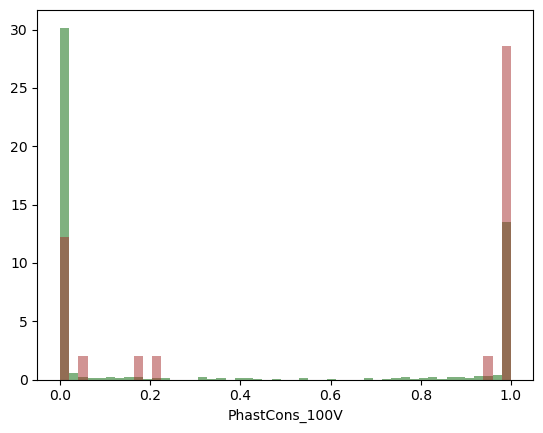

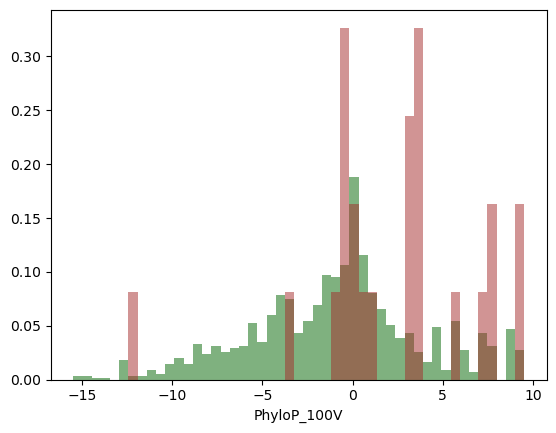

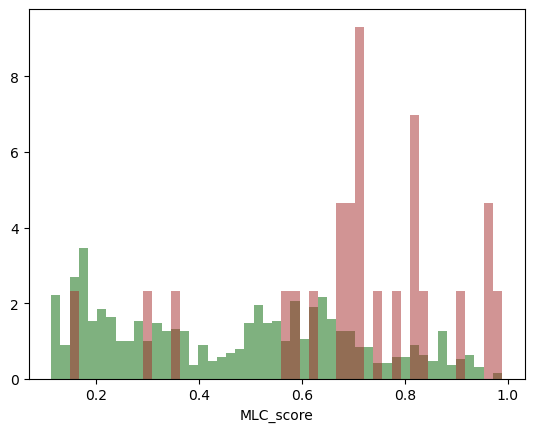

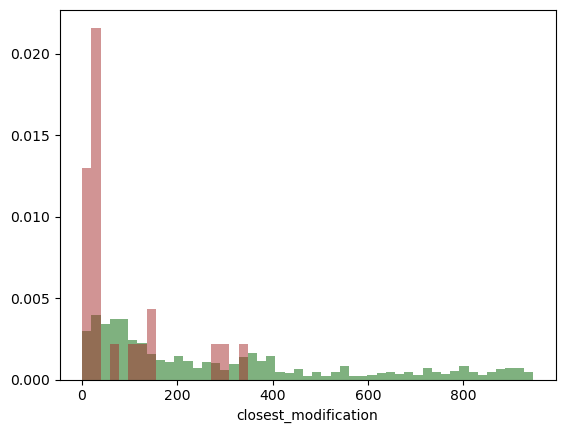

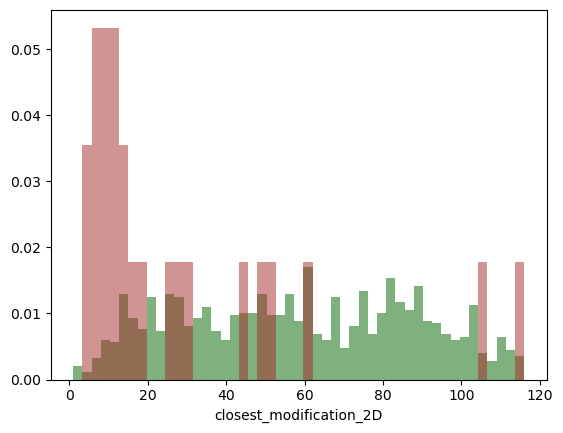

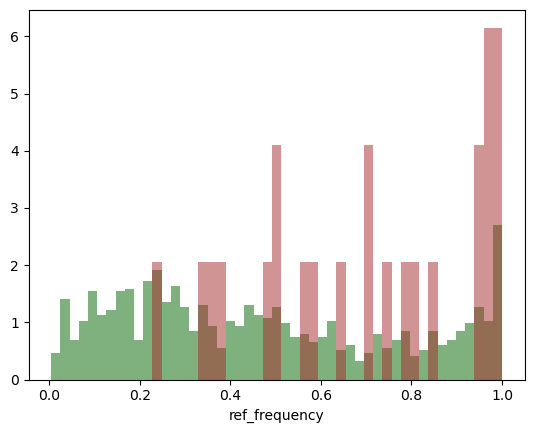

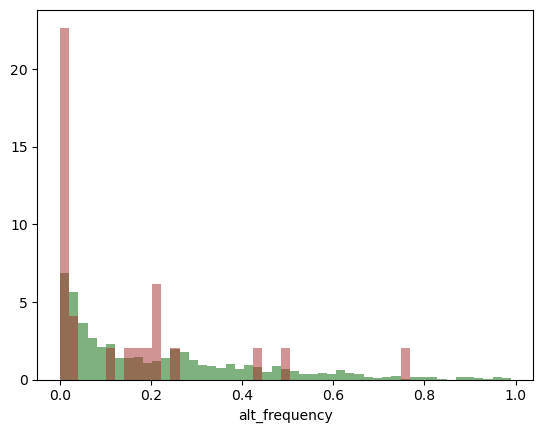

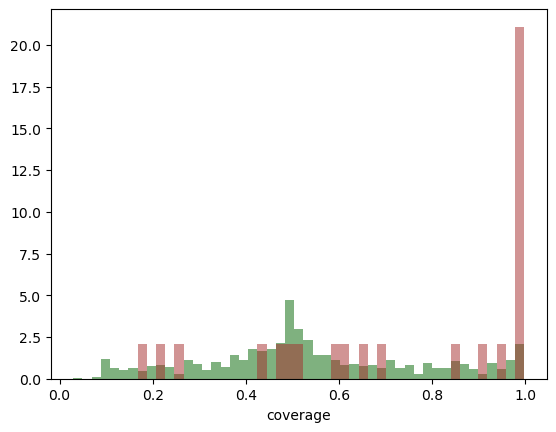

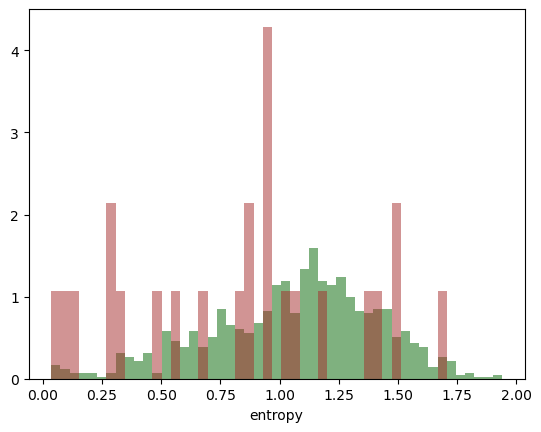

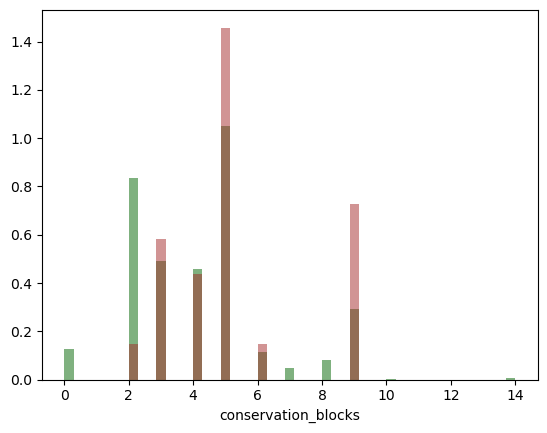

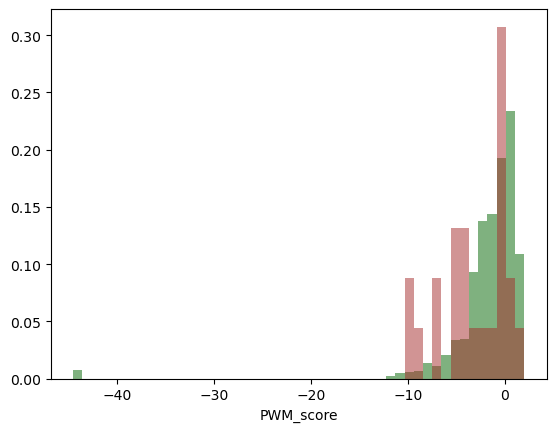

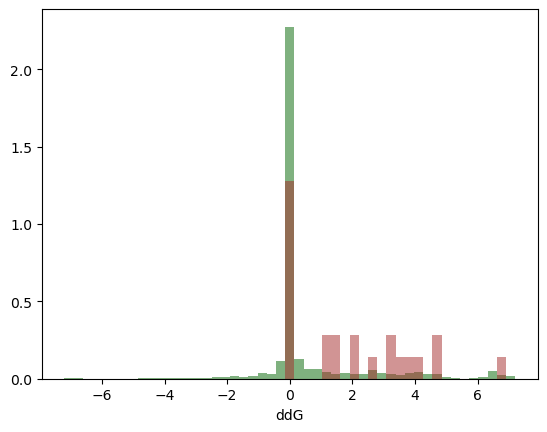

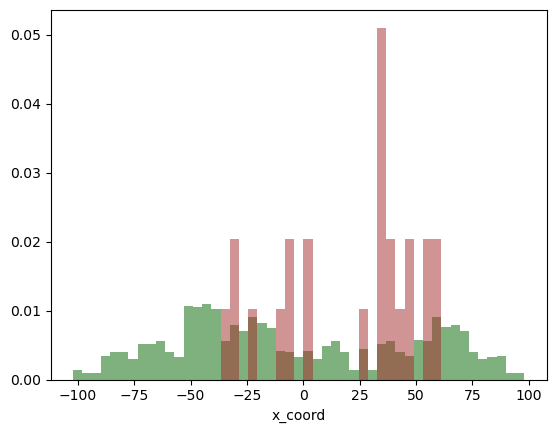

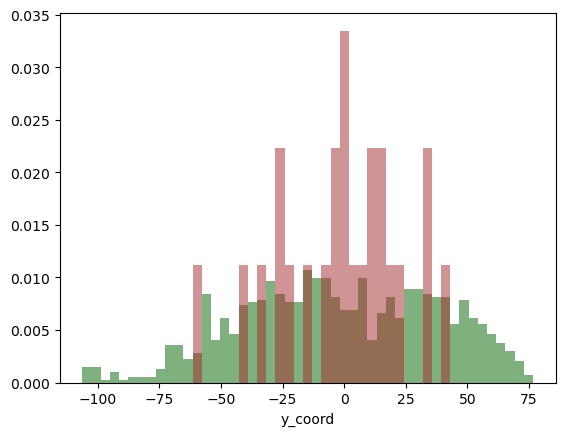

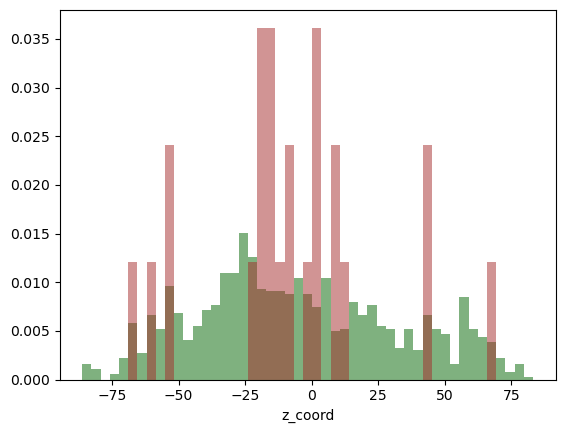

In [5]:
for feature in X.columns:
    plt.hist(X.loc[y==0, feature], density=True, alpha=.5, color="darkgreen", bins=(np.linspace(X[feature].min(), X[feature].max(), 50)))
    plt.hist(X.loc[y==1, feature], density=True, alpha=.5, color="brown", bins=(np.linspace(X[feature].min(), X[feature].max(), 50)))
    plt.xlabel(feature)
    plt.show()

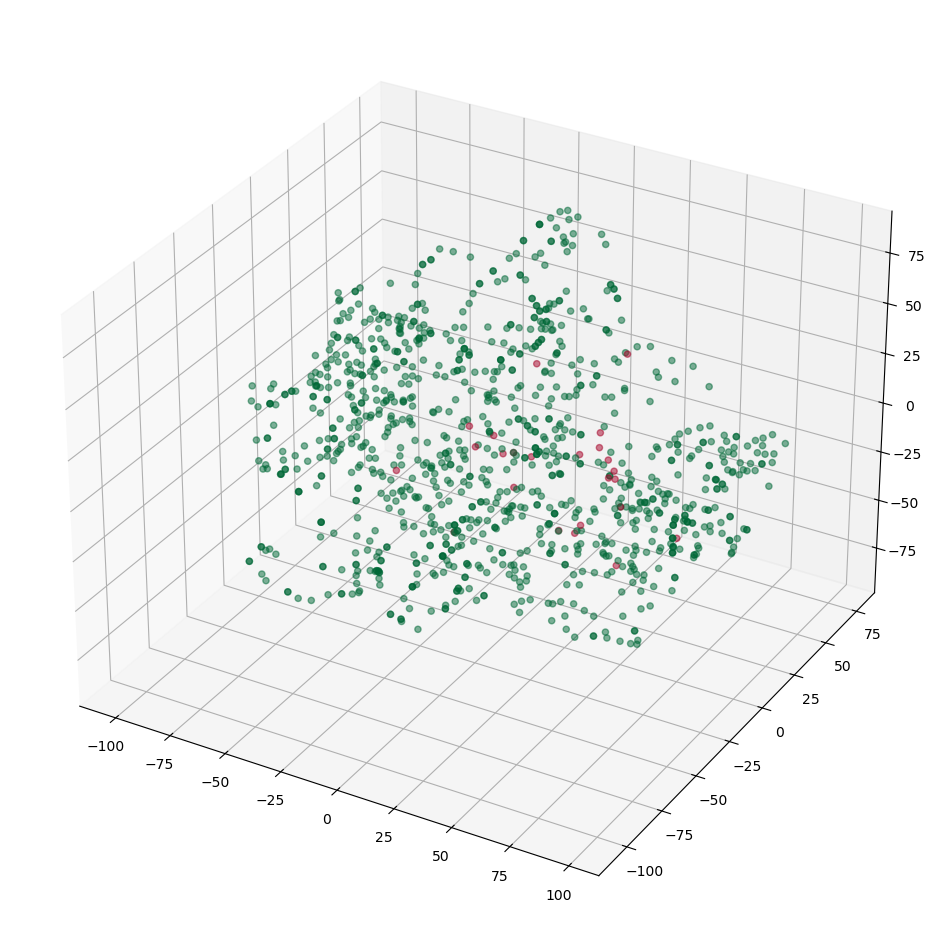

In [6]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')

ax.scatter(X.x_coord, X.y_coord, X.z_coord, c=y, cmap="RdYlGn_r", alpha=.5)
plt.show()

In [7]:
from sklearn.metrics import roc_auc_score
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

In [8]:
N_ESTIMATORS = 4096
N_ESTIMATORS

4096

In [9]:
# preprocessing steps

from sklearn import clone
from scipy import stats
from sklearn.feature_selection import f_classif
from CustomEstimators.FilterByCorrelation import FilterByCorrelation
from CustomEstimators.PartialPCA import PartialPCA
from CustomEstimators.DataFrameUtils import ColumnTransformerDF, SelectFdrDF, SelectFromModelDF, StandardScalerDF


feature_selection = SelectFromModelDF(
    DecisionTreeClassifier(class_weight="balanced", random_state=777), threshold=.01
)

channel_selection = SelectFdrDF(f_classif, alpha=.01)

input_selection = ColumnTransformerDF([
    ("feature_selection", feature_selection, X.columns),
    ("channel_selection", channel_selection, embedding.columns),
], verbose_feature_names_out=False)

channels_correlation_filter = FilterByCorrelation(
    stats.spearmanr,
    features_to_filter=X_extended.columns[(X_extended.columns.str.match("channel_"))], 
    test_features=X_extended.columns[~(X_extended.columns.str.match("channel_"))],
    corr_threshold=0.25
)

scaler = StandardScalerDF()

channels_pca = PartialPCA(
    n_components=5, pca_features=embedding.columns
)

In [10]:
# classifier and tuner

from sklearn.model_selection import ParameterGrid
from sklearn.svm import SVC
from CustomEstimators.GridSearchOOB_BinaryClassifier import GridSearchOOB_BinaryClassifier
from imblearn.ensemble import BalancedBaggingClassifier


grid_svc = ParameterGrid({
    "estimator__C": [0.1, 1, 10, 100],
    "estimator__gamma": ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1, 1.],
    "max_features": [.1, .25, .5, .75, 1.],
})

gridsearch_svc = GridSearchOOB_BinaryClassifier(
    estimator=BalancedBaggingClassifier(
        estimator=SVC(kernel="rbf", probability=True),
        n_estimators=N_ESTIMATORS, oob_score=True, replacement=True, bootstrap=True,
        sampling_strategy="not minority", n_jobs=-1
    ),
    param_grid=grid_svc,
    scoring_function=roc_auc_score,
    n_jobs=16,
    verbose=True
)

model_svc = Pipeline([
    ("input_selection", clone(input_selection)),
    ('channels_correlation_filter', clone(channels_correlation_filter)),
    ("scaler", clone(scaler)),
    ("channels_pca", clone(channels_pca)),
    ("gridsearch", clone(gridsearch_svc)),
])

model_svc

Pipeline(steps=[('input_selection',
                 ColumnTransformerDF(transformers=[('feature_selection',
                                                    SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                       random_state=777),
                                                                      threshold=0.01),
                                                    Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'closest_modification',
       'closest_modification_2D', 'ref_frequency', 'alt_frequency', 'coverage',
       'entropy'...
                 GridSearchOOB_BinaryClassifier(estimator=BalancedBaggingClassifier(estimator=SVC(probability=True),
                                                                                    n_estimators=4096,
                                                                                    n_jobs=-1,
                                                                                    oob_score=True,
                                                                                    replacement=True,
                                                                                    sampling_strategy='not '
                                                                                                      'minority'),
                                                n_jobs=16,
                                                param_grid=<sklearn.model_selection._search.ParameterGrid object at 0x79c3f09fbd90>,
                                                scoring_function=<function roc_auc_score at 0x79c3f1d3a8e0>,
                                                verbose=True))])

In [11]:
model_svc.fit(X_extended, y)

Pipeline(steps=[('input_selection',
                 ColumnTransformerDF(transformers=[('feature_selection',
                                                    SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                       random_state=777),
                                                                      threshold=0.01),
                                                    Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'closest_modification',
       'closest_modification_2D', 'ref_frequency', 'alt_frequency', 'coverage',
       'entropy'...
                 GridSearchOOB_BinaryClassifier(estimator=BalancedBaggingClassifier(estimator=SVC(C=100,
                                                                                                  gamma=0.01,
                                                                                                  probability=True),
                                                                                    n_estimators=4096,
                                                                                    n_jobs=-1,
                                                                                    oob_score=True,
                                                                                    replacement=True,
                                                                                    sampling_strategy='not '
                                                                                                      'minority'),
                                                n_jobs=16,
                                                param_grid=<sklearn.model_selection._search.ParameterGrid object at 0x79c3f09fbd90>,
                                                scoring_function=<function roc_auc_score at 0x79c3f1d3a8e0>,
                                                verbose=True))])

In [12]:
roc_auc_score(y, model_svc[-1].estimator.oob_decision_function_[:,1])

np.float64(0.8604127134724857)

In [13]:
pk.dump(model_svc, open("checkpoints/candidate_models/model_svc.pk", "wb"))

In [54]:
grid_rf = ParameterGrid({
    "criterion": ["gini", "entropy"],
    "max_features": [.1, .25, .5, .75, 1.0],
    "max_depth": [3, 5, 7, 9, 11, 13, 15, 17, 21, 25],
})

gridsearch_rf = GridSearchOOB_BinaryClassifier(
    estimator=BalancedRandomForestClassifier(
        n_estimators=N_ESTIMATORS, sampling_strategy={0:22, 1:22},
        oob_score=True, bootstrap=True, n_jobs=-1
    ),
    param_grid=grid_rf, scoring_function=roc_auc_score,
    n_jobs=16, verbose=99
)

model_rf = Pipeline([
    ("input_selection", clone(input_selection)),
    ('channels_correlation_filter', clone(channels_correlation_filter)),
    ("scaler", clone(scaler)),
    ("channels_pca", clone(channels_pca)),
    ("gridsearch", clone(gridsearch_rf)),
])

In [55]:
model_rf.fit(X_extended, y)

Pipeline(steps=[('input_selection',
                 ColumnTransformerDF(transformers=[('feature_selection',
                                                    SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                       random_state=777),
                                                                      threshold=0.01),
                                                    Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'closest_modification',
       'closest_modification_2D', 'ref_frequency', 'alt_frequency', 'coverage',
       'entropy'...
                 GridSearchOOB_BinaryClassifier(estimator=BalancedRandomForestClassifier(bootstrap=True,
                                                                                         criterion='entropy',
                                                                                         max_depth=9,
                                                                                         max_features=0.1,
                                                                                         n_estimators=4096,
                                                                                         n_jobs=-1,
                                                                                         oob_score=True,
                                                                                         sampling_strategy={0: 22,
                                                                                                            1: 22}),
                                                n_jobs=16,
                                                param_grid=<sklearn.model_selection._search.ParameterGrid object at 0x7236654bfd90>,
                                                scoring_function=<function roc_auc_score at 0x7236621ee700>,
                                                verbose=99))])

In [ ]:
pk.dump(model_rf, open("checkpoints/candidate_models/model_rf.pk", "wb"))

In [56]:
roc_auc_score(y, model_rf[-1].estimator.oob_decision_function_[:,1])

np.float64(0.9836337760910816)

In [14]:
from sklearn.neighbors import KNeighborsClassifier


grid_knn = ParameterGrid({
    "estimator__weights": ["uniform", "distance"],
    'estimator__n_neighbors': [1, 2, 3, 4, 5, 7, 9, 11, 15, 19, 21, 25, 30],
    "max_features": [.1, .25, .5, .75, 1.],
})

gridsearch_knn = GridSearchOOB_BinaryClassifier(
    estimator=BalancedBaggingClassifier(
        estimator=KNeighborsClassifier(metric="euclidean"),
        n_estimators=N_ESTIMATORS, oob_score=True, replacement=True, bootstrap=True,
        sampling_strategy="not minority", n_jobs=-1
    ),
    param_grid=grid_knn, scoring_function=roc_auc_score,
    n_jobs=32, verbose=99
)

model_knn = Pipeline([
    ("input_selection", clone(input_selection)),
    ('channels_correlation_filter', clone(channels_correlation_filter)),
    ("scaler", clone(scaler)),
    ("channels_pca", clone(channels_pca)),
    ("gridsearch", clone(gridsearch_knn)),
])

In [15]:
model_knn.fit(X_extended, y)

nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope
nope


Pipeline(steps=[('input_selection',
                 ColumnTransformerDF(transformers=[('feature_selection',
                                                    SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                       random_state=777),
                                                                      threshold=0.01),
                                                    Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'closest_modification',
       'closest_modification_2D', 'ref_frequency', 'alt_frequency', 'coverage',
       'entropy'...
                 GridSearchOOB_BinaryClassifier(estimator=BalancedBaggingClassifier(estimator=KNeighborsClassifier(metric='euclidean',
                                                                                                                   n_neighbors=3),
                                                                                    max_features=0.1,
                                                                                    n_estimators=4096,
                                                                                    n_jobs=-1,
                                                                                    oob_score=True,
                                                                                    replacement=True,
                                                                                    sampling_strategy='not '
                                                                                                      'minority'),
                                                n_jobs=32,
                                                param_grid=<sklearn.model_selection._search.ParameterGrid object at 0x79c4f20ce2c0>,
                                                scoring_function=<function roc_auc_score at 0x79c3f1d3a8e0>,
                                                verbose=99))])

In [17]:
pk.dump(model_knn, open("checkpoints/candidate_models/model_knn.pk", "wb"))

In [16]:
roc_auc_score(y, model_knn[-1].estimator.oob_decision_function_[:,1])

np.float64(0.9023561037318154)

In [18]:
#######################
###### checkpoint #####
#######################

model_svc = pk.load(open("checkpoints/candidate_models/model_svc.pk", "rb"))
model_rf = pk.load(open("checkpoints/candidate_models/model_rf.pk", "rb"))
model_knn = pk.load(open("checkpoints/candidate_models/model_knn.pk", "rb"))

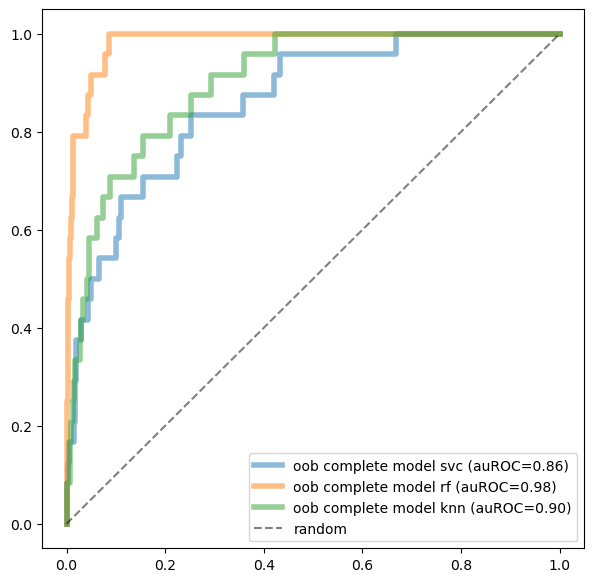

In [19]:
plt.figure(figsize=(7, 7))

fpr, tpr, _ = roc_curve(y, model_svc[-1].estimator.oob_decision_function_[:,1])
plt.plot(fpr, tpr, label="oob complete model svc (auROC=%.2f)"%(roc_auc_score(y, model_svc[-1].estimator.oob_decision_function_[:,1])), alpha=.5, linewidth=4)

fpr, tpr, _ = roc_curve(y, model_rf[-1].estimator.oob_decision_function_[:,1])
plt.plot(fpr, tpr, label="oob complete model rf (auROC=%.2f)"%(roc_auc_score(y, model_rf[-1].estimator.oob_decision_function_[:,1])), alpha=.5, linewidth=4)

fpr, tpr, _ = roc_curve(y, model_knn[-1].estimator.oob_decision_function_[:,1])
plt.plot(fpr, tpr, label="oob complete model knn (auROC=%.2f)"%(roc_auc_score(y, model_knn[-1].estimator.oob_decision_function_[:,1])), alpha=.5, linewidth=4)

plt.plot([0, 1], [0, 1], color='k', linestyle='--', label="random", alpha=.5)

plt.legend()
plt.show()

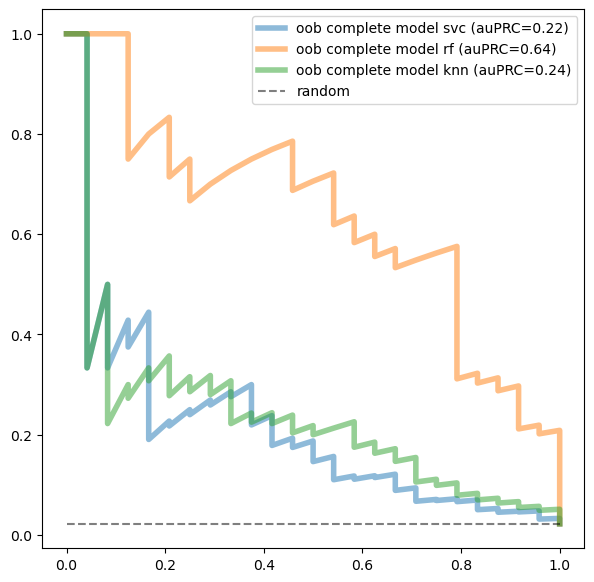

In [22]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Create the figure
plt.figure(figsize=(7, 7))

# Plot auPRC for the second model (SVC)
precision, recall, _ = precision_recall_curve(y, model_svc[-1].estimator.oob_decision_function_[:, 1])
plt.plot(recall, precision, label="oob complete model svc (auPRC=%.2f)" % average_precision_score(y, model_svc[-1].estimator.oob_decision_function_[:, 1]), alpha=0.5, linewidth=4)

# Plot auPRC for the third model (Random Forest)
precision, recall, _ = precision_recall_curve(y, model_rf[-1].estimator.oob_decision_function_[:, 1])
plt.plot(recall, precision, label="oob complete model rf (auPRC=%.2f)" % average_precision_score(y, model_rf[-1].estimator.oob_decision_function_[:, 1]), alpha=0.5, linewidth=4)

# Plot auPRC for the fourth model (KNN)
precision, recall, _ = precision_recall_curve(y, model_knn[-1].estimator.oob_decision_function_[:, 1])
plt.plot(recall, precision, label="oob complete model knn (auPRC=%.2f)" % average_precision_score(y, model_knn[-1].estimator.oob_decision_function_[:, 1]), alpha=0.5, linewidth=4)

# Random classifier line (dashed line as a baseline)
plt.plot([0, 1], [y.mean(), y.mean()], color='k', linestyle='--', label="random", alpha=0.5)

# Adding legend and showing the plot
plt.legend()
plt.show()

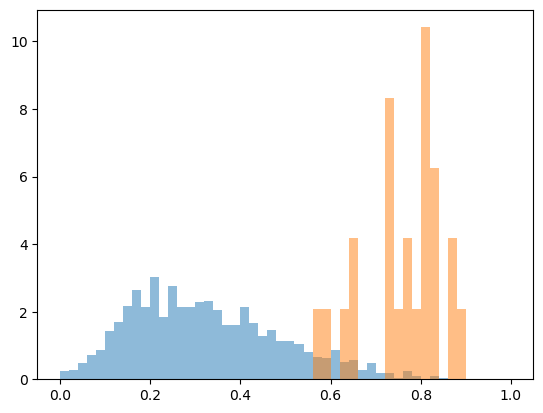

In [23]:
plt.hist(model_rf[-1].oob_decision_function_[y==0, 1], bins=np.linspace(0,1,51), alpha=.5, density=True)
plt.hist(model_rf[-1].oob_decision_function_[y==1, 1], bins=np.linspace(0,1,51), alpha=.5, density=True)
plt.show()

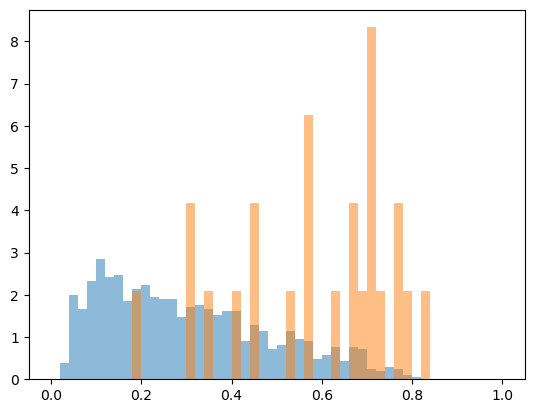

In [24]:
plt.hist(model_svc[-1].oob_decision_function_[y==0, 1], bins=np.linspace(0,1,51), alpha=.5, density=True)
plt.hist(model_svc[-1].oob_decision_function_[y==1, 1], bins=np.linspace(0,1,51), alpha=.5, density=True)
plt.show()

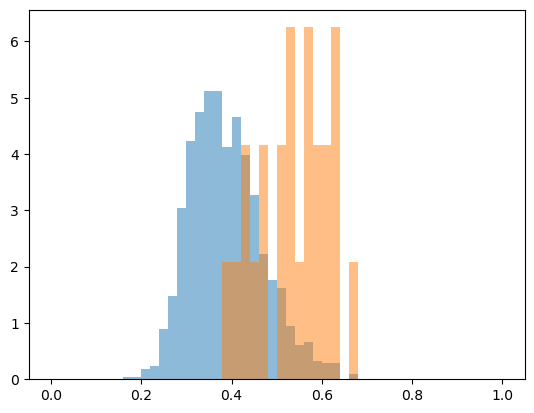

In [25]:
plt.hist(model_knn[-1].oob_decision_function_[y==0, 1], bins=np.linspace(0,1,51), alpha=.5, density=True)
plt.hist(model_knn[-1].oob_decision_function_[y==1, 1], bins=np.linspace(0,1,51), alpha=.5, density=True)
plt.show()

In [ ]:
#######################################################
### 24-fold CV to assess generalization performance ###
######## (this is huge and may require hours) #########
#######################################################

In [29]:
from sklearn.model_selection import cross_validate, RepeatedStratifiedKFold

kfold = RepeatedStratifiedKFold(n_splits=24, n_repeats=1, random_state=420)

cross_validation_result = cross_validate(
    clone(model_rf), X_extended, y, scoring=binary_auROC,
    cv=kfold, return_estimator=True,
    n_jobs=1, error_score="raise", verbose=99,
)
cross_validation_result

[CV] START .....................................................................


/home/saldan/Desktop/projects/rPOGEE/CustomEstimators/PartialPCA.py:38: UserWarning: WARNING: n_components > feature pca features. Setting n_components to 2.
  warnings.warn(f"WARNING: n_components > feature pca features. Setting n_components to {self.n_features_in_pca}.")


[CV] END ......................................., score=1.000 total time= 1.5min
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:  1.5min
[CV] START .....................................................................
[CV] END ......................................., score=0.386 total time= 1.5min
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:  3.0min
[CV] START .....................................................................
[CV] END ......................................., score=0.932 total time= 1.5min
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:  4.6min
[CV] START .....................................................................


/home/saldan/Desktop/projects/rPOGEE/CustomEstimators/PartialPCA.py:38: UserWarning: WARNING: n_components > feature pca features. Setting n_components to 4.
  warnings.warn(f"WARNING: n_components > feature pca features. Setting n_components to {self.n_features_in_pca}.")


[CV] END ......................................., score=1.000 total time= 1.5min
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:  6.1min
[CV] START .....................................................................
[CV] END ......................................., score=0.932 total time= 1.5min
[Parallel(n_jobs=1)]: Done   5 tasks      | elapsed:  7.6min
[CV] START .....................................................................
[CV] END ......................................., score=1.000 total time= 1.5min
[Parallel(n_jobs=1)]: Done   6 tasks      | elapsed:  9.2min
[CV] START .....................................................................
[CV] END ......................................., score=0.477 total time= 1.6min
[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed: 10.7min
[CV] START .....................................................................
[CV] END ......................................., score=0.932 total time= 1.5min
[Parallel(n_jobs=1)]: Done 

...

/home/saldan/Desktop/projects/rPOGEE/CustomEstimators/PartialPCA.py:38: UserWarning: WARNING: n_components > feature pca features. Setting n_components to 4.
  warnings.warn(f"WARNING: n_components > feature pca features. Setting n_components to {self.n_features_in_pca}.")


[CV] END ......................................., score=1.000 total time= 1.5min
[Parallel(n_jobs=1)]: Done  15 tasks      | elapsed: 23.0min
[CV] START .....................................................................
[CV] END ......................................., score=0.727 total time= 1.5min
[Parallel(n_jobs=1)]: Done  16 tasks      | elapsed: 24.5min
[CV] START .....................................................................
[CV] END ......................................., score=0.977 total time= 1.5min
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed: 26.0min
[CV] START .....................................................................
[CV] END ......................................., score=0.455 total time= 1.5min
[Parallel(n_jobs=1)]: Done  18 tasks      | elapsed: 27.6min
[CV] START .....................................................................
[CV] END ......................................., score=0.955 total time= 1.5min
[Parallel(n_jobs=1)]: Done 

/home/saldan/Desktop/projects/rPOGEE/CustomEstimators/PartialPCA.py:38: UserWarning: WARNING: n_components > feature pca features. Setting n_components to 4.
  warnings.warn(f"WARNING: n_components > feature pca features. Setting n_components to {self.n_features_in_pca}.")


[CV] END ......................................., score=0.955 total time= 1.5min
[Parallel(n_jobs=1)]: Done  22 tasks      | elapsed: 33.6min
[CV] START .....................................................................
[CV] END ......................................., score=0.977 total time= 1.5min
[Parallel(n_jobs=1)]: Done  23 tasks      | elapsed: 35.2min
[CV] START .....................................................................
[CV] END ......................................., score=1.000 total time= 1.6min
[Parallel(n_jobs=1)]: Done  24 tasks      | elapsed: 36.7min
[Parallel(n_jobs=1)]: Done  24 tasks      | elapsed: 36.7min


{'fit_time': array([90.24898696, 90.10867882, 92.26706839, 90.65038633, 92.05912828,
        92.06455255, 92.68276525, 91.18486881, 91.74707294, 92.34313869,
        91.01017165, 91.2614553 , 91.6253767 , 91.57285142, 91.59210563,
        91.70490551, 90.73963332, 90.59774256, 91.00606203, 90.14466929,
        92.34644651, 90.08095884, 90.87416387, 92.8532784 ]),
 'score_time': array([0.3794539 , 0.41685748, 0.36084485, 0.49125266, 0.43110752,
        0.41755199, 0.48893213, 0.48566604, 0.44504547, 0.45262218,
        0.45620441, 0.46622038, 0.43602514, 0.44723868, 0.44817257,
        0.44797063, 0.42324781, 0.47598219, 0.43960476, 0.42581224,
        0.48313427, 0.42177558, 0.49206829, 0.41226864]),
 'estimator': [Pipeline(steps=[('input_selection',
                   ColumnTransformerDF(transformers=[('feature_selection',
                                                      SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                  

In [30]:
cv_predictions = [
    pipe.predict_proba(X_extended.iloc[test])[:,1]
    for (train, test), pipe in zip(kfold.split(X_extended, y), cross_validation_result["estimator"])
]
cv_predictions

[array([0.18115234, 0.2590332 , 0.16772461, 0.41040039, 0.21850586,
        0.25512695, 0.16113281, 0.21508789, 0.31420898, 0.4921875 ,
        0.49047852, 0.73754883, 0.87451172, 0.64746094, 0.64331055,
        0.65258789, 0.17919922, 0.12719727, 0.17895508, 0.11816406,
        0.12866211, 0.1003418 , 0.23803711, 0.39746094, 0.19091797,
        0.29907227, 0.31689453, 0.06616211, 0.11865234, 0.13012695,
        0.16650391, 0.41479492, 0.1628418 , 0.17211914, 0.17773438,
        0.34033203, 0.40795898, 0.46948242, 0.47094727, 0.26245117,
        0.20507812, 0.17700195, 0.38598633, 0.70336914, 0.19897461]),
 array([0.25170898, 0.26464844, 0.23046875, 0.29760742, 0.20703125,
        0.30297852, 0.15429688, 0.21484375, 0.28637695, 0.43066406,
        0.56274414, 0.53588867, 0.13330078, 0.25219727, 0.12963867,
        0.31347656, 0.06860352, 0.15698242, 0.19702148, 0.15307617,
        0.39282227, 0.33007812, 0.36938477, 0.43286133, 0.40405273,
        0.24682617, 0.3046875 , 0.13525391, 0.

In [31]:
cv_ground_truth = [
    y.iloc[test]
    for train, test in kfold.split(X_extended, y)
]
cv_ground_truth

[Mithril_id
 MITHRIL.2036    0
 MITHRIL.2168    0
 MITHRIL.2437    0
 MITHRIL.2463    0
 MITHRIL.2876    0
 MITHRIL.2895    0
 MITHRIL.3005    0
 MITHRIL.3051    0
 MITHRIL.3352    0
 MITHRIL.3970    0
 MITHRIL.4022    0
 MITHRIL.4493    0
 MITHRIL.4730    1
 MITHRIL.4753    0
 MITHRIL.4782    0
 MITHRIL.4786    0
 MITHRIL.5368    0
 MITHRIL.5419    0
 MITHRIL.5524    0
 MITHRIL.5604    0
 MITHRIL.5672    0
 MITHRIL.5670    0
 MITHRIL.5742    0
 MITHRIL.5862    0
 MITHRIL.5881    0
 MITHRIL.5929    0
 MITHRIL.6103    0
 MITHRIL.6165    0
 MITHRIL.6478    0
 MITHRIL.6727    0
 MITHRIL.7133    0
 MITHRIL.7147    0
 MITHRIL.7157    0
 MITHRIL.7164    0
 MITHRIL.7239    0
 MITHRIL.7268    0
 MITHRIL.7324    0
 MITHRIL.7691    0
 MITHRIL.7912    0
 MITHRIL.8116    0
 MITHRIL.8651    0
 MITHRIL.8710    0
 MITHRIL.8911    0
 MITHRIL.9298    0
 MITHRIL.9593    0
 Name: label, dtype: int64,
 Mithril_id
 MITHRIL.2095    0
 MITHRIL.2114    0
 MITHRIL.2194    0
 MITHRIL.2253    0
 MITHRIL.2423    

In [28]:
pk.dump((cv_ground_truth, cv_predictions), open("checkpoints/cross_validation_test.pk", "wb"))

In [29]:
cv_ground_truth, cv_predictions = pk.load(open("checkpoints/cross_validation_test.pk", "rb"))
cv_ground_truth, cv_predictions

([Mithril_id
  MITHRIL.2036    0
  MITHRIL.2168    0
  MITHRIL.2437    0
  MITHRIL.2463    0
  MITHRIL.2876    0
  MITHRIL.2895    0
  MITHRIL.3005    0
  MITHRIL.3051    0
  MITHRIL.3352    0
  MITHRIL.3970    0
  MITHRIL.4022    0
  MITHRIL.4493    0
  MITHRIL.4730    1
  MITHRIL.4753    0
  MITHRIL.4782    0
  MITHRIL.4786    0
  MITHRIL.5368    0
  MITHRIL.5419    0
  MITHRIL.5524    0
  MITHRIL.5604    0
  MITHRIL.5672    0
  MITHRIL.5670    0
  MITHRIL.5742    0
  MITHRIL.5862    0
  MITHRIL.5881    0
  MITHRIL.5929    0
  MITHRIL.6103    0
  MITHRIL.6165    0
  MITHRIL.6478    0
  MITHRIL.6727    0
  MITHRIL.7133    0
  MITHRIL.7147    0
  MITHRIL.7157    0
  MITHRIL.7164    0
  MITHRIL.7239    0
  MITHRIL.7268    0
  MITHRIL.7324    0
  MITHRIL.7691    0
  MITHRIL.7912    0
  MITHRIL.8116    0
  MITHRIL.8651    0
  MITHRIL.8710    0
  MITHRIL.8911    0
  MITHRIL.9298    0
  MITHRIL.9593    0
  Name: label, dtype: int64,
  Mithril_id
  MITHRIL.2095    0
  MITHRIL.2114    0
  MIT

In [30]:
np.mean([roc_auc_score(y_true, y_pred) for y_pred, y_true in zip(cv_predictions, cv_ground_truth)])

np.float64(0.874504492600423)

In [31]:
np.mean([average_precision_score(y_true, y_pred) for y_pred, y_true in zip(cv_predictions, cv_ground_truth)])

np.float64(0.4891971916971916)

In [32]:
pathogenic_variant_quantile = np.array([(y_pred[y_true==1][0]>=y_pred).mean() for y_pred, y_true in zip(cv_predictions, cv_ground_truth)])
pathogenic_variant_quantile

array([1.        , 0.4       , 0.93333333, 1.        , 0.93333333,
       1.        , 0.48888889, 0.93333333, 1.        , 0.95555556,
       0.84444444, 1.        , 0.82222222, 0.71111111, 1.        ,
       0.73333333, 0.97777778, 0.46666667, 0.95555556, 1.        ,
       0.97777778, 0.95555556, 0.97727273, 1.        ])

<Figure size 700x700 with 0 Axes>

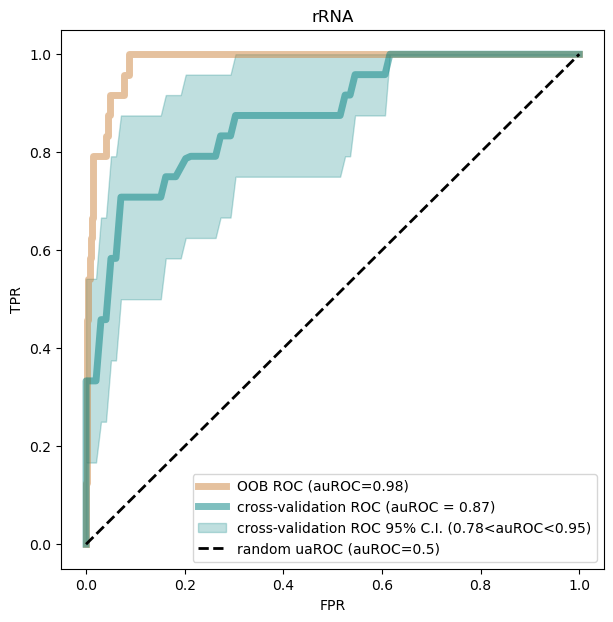

In [33]:
plt.figure(figsize=(7,7))

plt.figure(figsize=(7,7))

#################################
############ OOB ROC ############
#################################

fpr, tpr, _ = roc_curve(y, model_rf[-1].estimator.oob_decision_function_[:,1])
plt.plot(
    fpr, tpr,
    label="OOB ROC (auROC=%.2f)"%roc_auc_score(y, model_rf[-1].estimator.oob_decision_function_[:,1]),
    linewidth=5, alpha=.5, color="peru"
)


#################################
############ CV ROC #############
#################################

fpr_bins = np.linspace(0, 1, 100)
tprs = []
aucs = []

for y_true, y_pred in zip(cv_ground_truth, cv_predictions):
    fpr, tpr, _ = roc_curve(
        y_true, y_pred
    )
    tprs.append(np.interp(fpr_bins, fpr, tpr))
    
    aucs.append(
        roc_auc_score(
            y_true, y_pred
        )
    )
    
    #plt.plot(fpr, tpr, linewidth=1, alpha=0.5, color="teal")

# Compute mean TPR and standard deviation across folds
fpr_bins = np.concat([[0.], fpr_bins, [1.]])
mean_tpr = np.concat([[0.], np.mean(tprs, axis=0), [1.]])
std_tpr = np.concat([[0.], np.std(tprs, axis=0), [0.]])

mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

# here we can do a binom conf interval since:
# ther's just one positive sample per fold -> tpr is in {0, 1} -> tpr is a bernoulli variable
low_tprs, high_tprs = stats.binom(24, (np.array(tprs)>=.5).mean(axis=0)).ppf([[.025], [.975]])/24
low_tprs = np.concat([[0.], low_tprs, [1.]])
high_tprs = np.concat([[0.], high_tprs, [1.]])


# Plot the average ROC curve
plt.plot(fpr_bins, mean_tpr, color="teal",
         label=r"cross-validation ROC (auROC = %0.2f)"%mean_auc,
         lw=5, alpha=.5)

plt.fill_between(
    fpr_bins, low_tprs, high_tprs,
    color="teal", alpha=.25,
    label="cross-validation ROC 95%% C.I. (%.2f<auROC<%.2f)"%(low_tprs.mean(), high_tprs.mean())
)


#################################
############ general ############
#################################


plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=2, label="random uaROC (auROC=0.5)")

plt.title("rRNA")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

In [ ]:
# TODO: remove this if it doesn't required anymore

In [35]:
# importances = pd.Series(
#     model_rf[-1].estimator.feature_importances_,
#     index=model_rf[-1].estimator.feature_names_in_
# )
# importances

In [36]:
# # use this mask to retrieve positional-free estimators

# np.array([
#     estimator.feature_importances_[importances.index.isin(["x_coord", "y_coord", "z_coord", "closest_modification"])].sum()==0
#     for estimator in model_rf[-1].estimator.estimators_
# ])

In [37]:
# importances.sort_values(ascending=False)